# Occupancy AI — TensorFlow Training Walkthrough

This notebook trains the room-occupancy classifier using the project's real sensor dataset. It presents each stage separately so that the data preparation, neural-network structure, training behaviour, evaluation, and STM32 export can be demonstrated clearly.

The notebook writes only to `notebook_run_english`; it does not replace the final model in `artifacts_pir_v2`.

## 1. Import libraries and locate the project files

TensorFlow/Keras builds and trains the neural network. Pandas and NumPy prepare the numerical data, while Matplotlib and Seaborn produce presentation-ready charts.

In [1]:
from pathlib import Path
import sys
import json
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from absl import logging as absl_logging

warnings.filterwarnings('ignore', category=UserWarning, module=r'tensorflow\.lite\.python\.(convert|converter|interpreter)')
tf.get_logger().setLevel('ERROR')
absl_logging.set_verbosity(absl_logging.ERROR)

ROOT = Path.cwd().resolve()
while not (ROOT / 'ai_module').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
MODULE_DIR = ROOT / 'ai_module' / 'tensorflow_occupancy'
WINDOWS_FILE = MODULE_DIR / 'window_features_v2.csv'
SPLIT_FILE = MODULE_DIR / 'split_config_v2.csv'
RUN_DIR = MODULE_DIR / 'notebook_run_english'
RUN_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(MODULE_DIR))

from train_tensorflow import (
    CLASS_NAMES, FEATURE_SETS, assign_recording_splits, build_model,
    balanced_class_weights, classification_metrics,
    convert_float_tflite, convert_int8_tflite, int8_predict,
)

tf.keras.utils.set_random_seed(2026)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print('TensorFlow version:', tf.__version__)
print('Project root:', ROOT)
print('Training windows:', WINDOWS_FILE)
print('Safe output folder:', RUN_DIR)

TensorFlow version: 2.21.0
Project root: C:\Users\ahmed\Downloads\VeCAD project AHMED
Training windows: ai_module\tensorflow_occupancy\window_features_v2.csv
Safe output folder: ai_module\tensorflow_occupancy\notebook_run_english


## 2. Load the 30-second windows and split the recording sessions

Each row represents approximately 30 seconds of recent PIR activity. Consecutive windows start five seconds apart. Complete recording sessions—not random rows—are assigned to training, validation, or testing to prevent data leakage.

Total windows: 1221
Selected model features: 6


,split,occupancy_label,windows,recordings
0,test,EMPTY,102,1
1,test,HIGH,97,1
2,test,LOW,57,1
3,train,EMPTY,144,2
4,train,HIGH,231,2
5,train,LOW,284,3
6,validation,EMPTY,69,1
7,validation,HIGH,127,1
8,validation,LOW,110,1


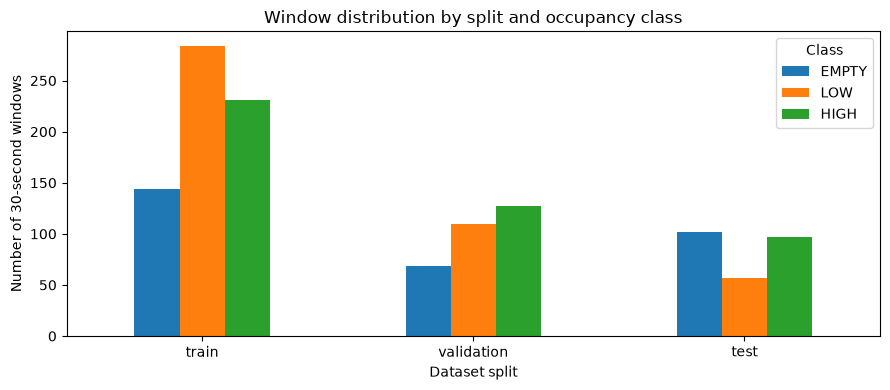

In [2]:
feature_names = FEATURE_SETS['pir']
data = assign_recording_splits(pd.read_csv(WINDOWS_FILE), SPLIT_FILE)
split_summary = (
    data.groupby(['split', 'occupancy_label'], as_index=False)
        .agg(windows=('window_id', 'size'), recordings=('recording_id', 'nunique'))
)
print('Total windows:', len(data))
print('Selected model features:', len(feature_names))
display(split_summary)

pivot = split_summary.pivot(index='split', columns='occupancy_label', values='windows')
pivot = pivot.reindex(index=['train', 'validation', 'test'], columns=CLASS_NAMES)
ax = pivot.plot(kind='bar', figsize=(9, 4), rot=0)
ax.set_title('Window distribution by split and occupancy class')
ax.set_xlabel('Dataset split')
ax.set_ylabel('Number of 30-second windows')
ax.legend(title='Class')
plt.tight_layout()
plt.savefig(RUN_DIR / '01_dataset_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Select the six PIR features and apply normalization

The model uses activity ratios and rising-edge counts from both PIR sensors. The mean and standard deviation are calculated from the training split only. The same constants are then applied to training, validation, testing, and later to live STM32 inputs.

`normalized = (feature − training mean) / training standard deviation`

In [3]:
splits = {name: data.loc[data['split'].eq(name)].copy() for name in ['train', 'validation', 'test']}
arrays = {
    name: (frame[feature_names].to_numpy(dtype=np.float32),
           frame['class_id'].to_numpy(dtype=np.int32))
    for name, frame in splits.items()
}
feature_mean = arrays['train'][0].mean(axis=0)
feature_std = arrays['train'][0].std(axis=0)
feature_std[feature_std < 1e-6] = 1.0
normalized_arrays = {
    name: (((inputs - feature_mean) / feature_std).astype(np.float32), labels)
    for name, (inputs, labels) in arrays.items()
}
normalization_table = pd.DataFrame({
    'feature': feature_names,
    'training_mean': feature_mean,
    'training_std': feature_std,
})
display(normalization_table.round(4))
print('Formula: normalized = (feature - training_mean) / training_std')

,feature,training_mean,training_std
0,pir_1_ratio,0.1833,0.1592
1,pir_2_ratio,0.1527,0.1534
2,pir_any_ratio,0.2980,0.2114
3,pir_both_ratio,0.0380,0.0625
4,pir_1_rising_edges,3.1775,2.7040
5,pir_2_rising_edges,2.2109,2.1994


Formula: normalized = (feature - training_mean) / training_std


## 4. Build the neural network

The network is a compact multilayer perceptron: **6 inputs → 16 ReLU neurons → 8 ReLU neurons → 3 Softmax outputs**. The three outputs represent `EMPTY`, `LOW`, and `HIGH`. With only 275 trainable parameters, the network is small enough for embedded deployment.

In [4]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(2026)
model = build_model(len(feature_names))
model.summary()
print('Optimizer: Adam, learning rate = 0.001')
print('Loss: Sparse Categorical Crossentropy')
print('Classes:', CLASS_NAMES)

Model: "occupancy_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalized_sensor_features      │ (None, 6)              │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ occupancy (Dense)               │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

Optimizer: Adam, learning rate = 0.001
Loss: Sparse Categorical Crossentropy
Classes: ['EMPTY', 'LOW', 'HIGH']


## 5. Train the model

Training uses the Adam optimizer, batches of 32 windows, and a maximum of 300 epochs. Class weights reduce bias caused by unequal class counts. Early Stopping monitors validation loss and restores the best weights if validation performance stops improving.

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=25, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=10, factor=0.5, min_lr=1e-5
    ),
]
history = model.fit(
    normalized_arrays['train'][0],
    normalized_arrays['train'][1],
    validation_data=normalized_arrays['validation'],
    epochs=300,
    batch_size=32,
    class_weight=balanced_class_weights(normalized_arrays['train'][1]),
    callbacks=callbacks,
    verbose=1,
)
history_df = pd.DataFrame(history.history)
history_df.to_csv(RUN_DIR / 'training_history.csv', index=False)
print('\nTraining completed after', len(history_df), 'epochs')

Epoch 1/300


 1/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1875 - loss: 1.2900

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4750 - loss: 1.0815 - val_accuracy: 0.5458 - val_loss: 1.0710 - learning_rate: 0.0010


Epoch 2/300


 1/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3438 - loss: 1.1164

...

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8832 - loss: 0.2562 - val_accuracy: 0.8072 - val_loss: 0.4734 - learning_rate: 2.5000e-04


Epoch 49/300


 1/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9062 - loss: 0.2646

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8832 - loss: 0.2559 - val_accuracy: 0.8007 - val_loss: 0.4737 - learning_rate: 2.5000e-04



Training completed after 49 epochs


## 6. Inspect the training curves

Accuracy shows the proportion of correct classifications. Loss measures how far the predicted probabilities are from the true labels. The comparison between training and validation curves helps reveal underfitting or overfitting.

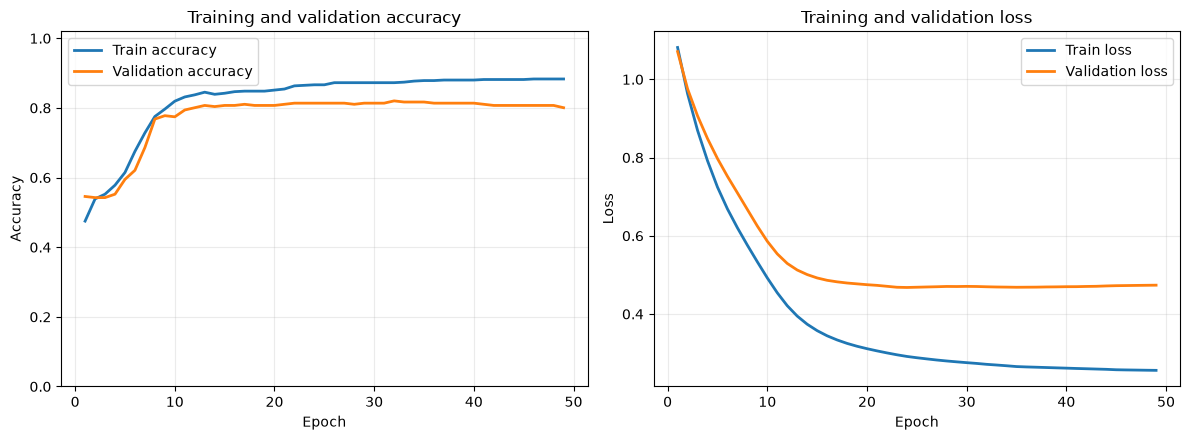

In [6]:
epochs = np.arange(1, len(history_df) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(epochs, history_df['accuracy'], label='Train accuracy', linewidth=2)
axes[0].plot(epochs, history_df['val_accuracy'], label='Validation accuracy', linewidth=2)
axes[0].set_title('Training and validation accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].plot(epochs, history_df['loss'], label='Train loss', linewidth=2)
axes[1].plot(epochs, history_df['val_loss'], label='Validation loss', linewidth=2)
axes[1].set_title('Training and validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.savefig(RUN_DIR / '02_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Evaluate on unseen test sessions

The test set contains complete recording sessions that were not used to update or select the model weights. The confusion matrix shows correct classifications on the diagonal and misclassifications outside the diagonal.

{
  "accuracy": 0.886719,
  "macro_f1": 0.874678,
  "per_class": {
    "EMPTY": {
      "precision": 0.971429,
      "recall": 1.0,
      "f1": 0.985507,
      "support": 102
    },
    "LOW": {
      "precision": 0.686747,
      "recall": 1.0,
      "f1": 0.814286,
      "support": 57
    },
    "HIGH": {
      "precision": 1.0,
      "recall": 0.701031,
      "f1": 0.824242,
      "support": 97
    }
  }
}


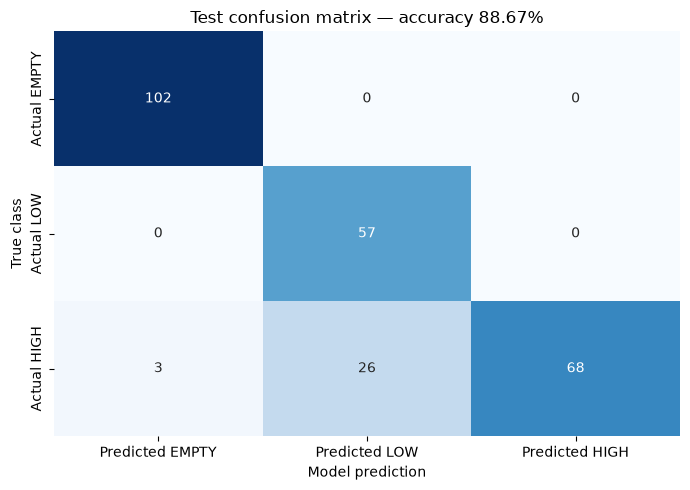

In [7]:
test_x, test_y = normalized_arrays['test']
test_probabilities = model.predict(test_x, verbose=0)
test_predicted = test_probabilities.argmax(axis=1)
test_metrics, test_matrix = classification_metrics(test_y, test_predicted)
print(json.dumps(test_metrics, indent=2))

matrix_df = pd.DataFrame(
    test_matrix,
    index=[f'Actual {name}' for name in CLASS_NAMES],
    columns=[f'Predicted {name}' for name in CLASS_NAMES],
)
plt.figure(figsize=(7, 5))
sns.heatmap(matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Test confusion matrix — accuracy {test_metrics['accuracy'] * 100:.2f}%")
plt.xlabel('Model prediction')
plt.ylabel('True class')
plt.tight_layout()
plt.savefig(RUN_DIR / '03_confusion_matrix_float.png', dpi=180, bbox_inches='tight')
plt.show()

## 8. Export and verify the TensorFlow Lite INT8 model

Full integer quantization reduces memory and computation requirements for STM32 deployment. The quantized model is evaluated again to confirm that the conversion preserves classification accuracy before it is imported into X-CUBE-AI.

In [8]:
model.save(RUN_DIR / 'occupancy_model.keras')
float_tflite = convert_float_tflite(model)
int8_tflite = convert_int8_tflite(model, normalized_arrays['train'][0])
(RUN_DIR / 'occupancy_model_float.tflite').write_bytes(float_tflite)
(RUN_DIR / 'occupancy_model_int8.tflite').write_bytes(int8_tflite)

int8_probabilities = int8_predict(int8_tflite, test_x)
int8_predicted = int8_probabilities.argmax(axis=1)
int8_metrics, int8_matrix = classification_metrics(test_y, int8_predicted)

print(f"Float TFLite size: {len(float_tflite):,} bytes")
print(f"INT8 TFLite size:  {len(int8_tflite):,} bytes")
print(f"Float test accuracy: {test_metrics['accuracy'] * 100:.2f}%")
print(f"INT8 test accuracy:  {int8_metrics['accuracy'] * 100:.2f}%")

Saved artifact at 'C:\Users\ahmed\AppData\Local\Temp\tmpvjfr1u2h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='normalized_sensor_features')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2513931829072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969288144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969287760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969287184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969288528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969286416: TensorSpec(shape=(), dtype=tf.resource, name=None)


Saved artifact at 'C:\Users\ahmed\AppData\Local\Temp\tmpfa2cr6dl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='normalized_sensor_features')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2513931829072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969288144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969287760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969287184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969288528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2513969286416: TensorSpec(shape=(), dtype=tf.resource, name=None)


Float TFLite size: 3,396 bytes


INT8 TFLite size:  3,616 bytes
Float test accuracy: 88.67%
INT8 test accuracy:  88.67%


## 9. Final training result — Presentation summary

This table summarizes the model architecture, data split, completed epochs, test accuracy, and final INT8 model size.

In [9]:
final_summary = pd.DataFrame({
    'Item': [
        'Input features', 'Architecture', 'Train windows',
        'Validation windows', 'Test windows', 'Epochs completed',
        'Float test accuracy', 'INT8 test accuracy', 'INT8 model size'
    ],
    'Result': [
        '6 PIR window features', '6 → 16 → 8 → 3',
        len(splits['train']), len(splits['validation']), len(splits['test']),
        len(history_df), f"{test_metrics['accuracy'] * 100:.2f}%",
        f"{int8_metrics['accuracy'] * 100:.2f}%", f"{len(int8_tflite):,} bytes"
    ]
})
display(final_summary.style.hide(axis='index').set_caption('Occupancy AI Training Results'))

result_payload = {
    'features': feature_names,
    'architecture': '6-16-8-3',
    'epochs_completed': len(history_df),
    'float_test_metrics': test_metrics,
    'int8_test_metrics': int8_metrics,
    'int8_model_size_bytes': len(int8_tflite),
}
(RUN_DIR / 'notebook_results.json').write_text(json.dumps(result_payload, indent=2), encoding='utf-8')
print('All outputs saved to:', RUN_DIR)

Item,Result
Input features,6 PIR window features
Architecture,6 → 16 → 8 → 3
Train windows,659
Validation windows,306
Test windows,256
Epochs completed,49
Float test accuracy,88.67%
INT8 test accuracy,88.67%
INT8 model size,"3,616 bytes"


All outputs saved to: ai_module\tensorflow_occupancy\notebook_run_english
